In [ ]:
#!/usr/bin/env python3
# mmca_stage_intervention_fixed.py
"""
Fixed MMCA on 3-uniform hypergraph with stage intervention. 外部干预
- Fixes issues when marking edges as [-1,-1,-1] by maintaining active_edges mask
- Adds option `rewire` to choose permanent deletion (no rewire) or random rewire
- Keeps the original pre/post pipeline and output CSV saving
"""

import os
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
from time import time

def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    """Generate a random 3-uniform hypergraph H(n,m,3) by sampling m distinct triples."""
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = np.random.choice(nodes, size=(batch_size, d), replace=True)
        # fix rows with duplicates
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = np.random.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

class HyperSISModel:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)    # shape (m,3)
        self.n = n
        self.m = self.hyperedges.shape[0]
        # convenience arrays (may contain -1 for deleted edges)
        self.edge_i = self.hyperedges[:, 0].copy()
        self.edge_j = self.hyperedges[:, 1].copy()
        self.edge_k = self.hyperedges[:, 2].copy()
        # mask of active edges (True = active)
        self.active_edges = np.ones(self.m, dtype=bool)
        # build incidence list
        self._build_node_incidence()

    def _build_node_incidence(self):
        """
        Build node_edge_pos: for each node, list of (edge_idx, position_in_edge).
        Ignores edges with active_edges==False or with negative node indices.
        """
        self.node_edge_pos = [[] for _ in range(self.n)]
        for ei in range(self.m):
            if not self.active_edges[ei]:
                continue
            a, b, c = self.hyperedges[ei]
            # safety: skip if any endpoint is invalid
            if a < 0 or b < 0 or c < 0:
                continue
            self.node_edge_pos[a].append((ei, 0))
            self.node_edge_pos[b].append((ei, 1))
            self.node_edge_pos[c].append((ei, 2))

    def _compute_edge_products(self, p):
        """
        Compute product of the two "other" nodes for each edge position:
          prod_pos0[e] = p_j * p_k  (when considering node edge_i)
          prod_pos1[e] = p_i * p_k
          prod_pos2[e] = p_i * p_j
        For inactive edges, return 0 so they don't contribute to infection.
        """
        # avoid negative indexing by clipping indices to valid range, but we'll mask after
        clip_idx_i = np.clip(self.edge_i, 0, self.n - 1)
        clip_idx_j = np.clip(self.edge_j, 0, self.n - 1)
        clip_idx_k = np.clip(self.edge_k, 0, self.n - 1)

        p_i = p[clip_idx_i]
        p_j = p[clip_idx_j]
        p_k = p[clip_idx_k]

        prod_pos0 = p_j * p_k
        prod_pos1 = p_i * p_k
        prod_pos2 = p_i * p_j

        # zero out contributions of inactive edges
        if not self.active_edges.all():
            mask = ~self.active_edges
            prod_pos0[mask] = 0.0
            prod_pos1[mask] = 0.0
            prod_pos2[mask] = 0.0

        return prod_pos0, prod_pos1, prod_pos2

    def _update_theta_from_p(self, p, Theta, eta, gamma):
        """
        Update Theta_e using Phi_e = product_j p_j for each edge.
        For inactive edges: set Phi=0 and Theta_new=0 (remain inactive).
        Returns Theta_new (length m) and Phi (length m).
        """
        # compute Phi using clipped indices then mask
        clip_idx_i = np.clip(self.edge_i, 0, self.n - 1)
        clip_idx_j = np.clip(self.edge_j, 0, self.n - 1)
        clip_idx_k = np.clip(self.edge_k, 0, self.n - 1)
        p_i = p[clip_idx_i]
        p_j = p[clip_idx_j]
        p_k = p[clip_idx_k]
        Phi = p_i * p_j * p_k

        # for inactive edges set Phi to 0 and Theta forced to 0
        if not self.active_edges.all():
            Phi[~self.active_edges] = 0.0

        Theta_new = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        # ensure inactive edges keep Theta=0
        if not self.active_edges.all():
            Theta_new[~self.active_edges] = 0.0

        Theta_new = np.clip(Theta_new, 0.0, 1.0)
        return Theta_new, Phi

    def _random_new_edge(self, existing_set, rng, d=3, max_tries=500):
        """
        Sample a fresh new d-tuple of nodes not in existing_set.
        rng is np.random.Generator or numpy.random module.
        """
        tries = 0
        while tries < max_tries:
            nodes = rng.choice(self.n, size=(d,), replace=False)
            nodes.sort()
            tup = tuple(int(x) for x in nodes.tolist())
            if tup not in existing_set:
                return np.array(nodes, dtype=int)
            tries += 1
        # last resort, return some sample (may collide)
        nodes = rng.choice(self.n, size=(d,), replace=False)
        nodes.sort()
        return np.array(nodes, dtype=int)

    def run_mmca_stage_intervention(self,
                                    beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                                    T_pre_max=200, T_post=100, init_frac=0.01,
                                    w_frac=0.1,   # fraction of edges to immunize at stage
                                    seed=None, verbose=False, rewire=True, theta_new_on_rewire=0.1):
        """
        Run MMCA pre-phase then stage intervention then post-phase.

        New parameter:
          rewire: bool, if False => permanently remove selected edges (no rewire).
                  if True  => rewire selected edges randomly (default behavior).
          theta_new_on_rewire: initial Theta for newly rewired edges (if rewire==True)

        Returns same structure as original function.
        """
        rng = np.random.default_rng(seed) if seed is not None else np.random

        # initialize p and Theta
        p = np.full(self.n, init_frac, dtype=float)
        Theta = np.ones(self.m, dtype=float) * 1.0
        edge_set = set(tuple(row.tolist()) for row in self.hyperedges if row[0] >= 0)

        pre_rho = []
        pre_theta_mean = []

        # pre-phase
        for t in range(T_pre_max):
            pre_rho.append(p.mean())
            pre_theta_mean.append(Theta.mean())

            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)

            # Q per node
            Q = np.ones(self.n, dtype=float)
            for node in range(self.n):
                prod_val = 1.0
                for (ei, pos) in self.node_edge_pos[node]:
                    # ignore inactive edges because node_edge_pos was built ignoring them
                    if pos == 0:
                        prod_oth = prod_pos0[ei]
                    elif pos == 1:
                        prod_oth = prod_pos1[ei]
                    else:
                        prod_oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
                Q[node] = prod_val

            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
            Theta, Phi = self._update_theta_from_p(p, Theta, eta, gamma)

            p = p_next

            # if verbose and (t % 50 == 0):
            #     print(f"[pre t={t}] rho={pre_rho[-1]:.6f}  meanTheta={pre_theta_mean[-1]:.6f}")

        # steady-time and pre summary
        t_ss = T_pre_max - 1
        pre_ss_rho_mean = float(pre_rho[-1])

        # compute Phi and select top edges
        p_for_phi = p.copy()
        # compute Phi for all edges (inactive ones will be zeroed in _update_theta_from_p)
        clip_idx_i = np.clip(self.edge_i, 0, self.n - 1)
        clip_idx_j = np.clip(self.edge_j, 0, self.n - 1)
        clip_idx_k = np.clip(self.edge_k, 0, self.n - 1)
        Phi_e = p_for_phi[clip_idx_i] * p_for_phi[clip_idx_j] * p_for_phi[clip_idx_k]
        # zero inactive edges to avoid selecting them
        if not self.active_edges.all():
            Phi_e[~self.active_edges] = 0.0

        sorted_idx = np.argsort(-Phi_e)
        num_rewire = max(1, int(np.ceil(w_frac * self.m))) if w_frac > 0 else 0
        top_idx = sorted_idx[:num_rewire]

        # Intervention: either permanently delete or rewire
        if num_rewire > 0:
            if rewire:
                # remove old tuples from edge_set first
                for ei in top_idx:
                    tup = tuple(int(x) for x in self.hyperedges[ei].tolist())
                    if tup in edge_set:
                        edge_set.remove(tup)
                    # mark temporarily inactive so we don't accidentally reuse same tuple
                    self.active_edges[ei] = False
                    # mark hyperedge placeholder to avoid duplication in set
                    self.hyperedges[ei] = np.array([-1, -1, -1], dtype=int)
                    Theta[ei] = 0.0
                # now create new edges for those positions
                for ei in top_idx:
                    new_edge = self._random_new_edge(existing_set=edge_set, rng=rng, d=3, max_tries=2000)
                    new_tup = tuple(int(x) for x in new_edge.tolist())
                    self.hyperedges[ei] = new_edge
                    self.edge_i[ei], self.edge_j[ei], self.edge_k[ei] = new_edge
                    edge_set.add(new_tup)
                    self.active_edges[ei] = True
                    Theta[ei] = float(theta_new_on_rewire)
                # rebuild incidence
                self._build_node_incidence()
            else:
                # permanent deletion: mark edges inactive and remove tuples
                for ei in top_idx:
                    tup = tuple(int(x) for x in self.hyperedges[ei].tolist())
                    if tup in edge_set:
                        edge_set.remove(tup)
                    self.hyperedges[ei] = np.array([-1, -1, -1], dtype=int)
                    self.active_edges[ei] = False
                    Theta[ei] = 0.0
                # update edge index arrays (keep -1 values)
                self.edge_i = self.hyperedges[:, 0].copy()
                self.edge_j = self.hyperedges[:, 1].copy()
                self.edge_k = self.hyperedges[:, 2].copy()
                # rebuild incidence which will ignore deleted edges
                self._build_node_incidence()

        # post-phase
        post_rho = []
        post_theta_mean = []
        for t in range(T_post):
            post_rho.append(p.mean())
            post_theta_mean.append(Theta.mean())

            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)

            Q = np.ones(self.n, dtype=float)
            for node in range(self.n):
                prod_val = 1.0
                for (ei, pos) in self.node_edge_pos[node]:
                    if pos == 0:
                        prod_oth = prod_pos0[ei]
                    elif pos == 1:
                        prod_oth = prod_pos1[ei]
                    else:
                        prod_oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
                Q[node] = prod_val

            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
            Theta, Phi = self._update_theta_from_p(p, Theta, eta, gamma)
            p = p_next

        # append final stats
        post_rho.append(p.mean())
        post_theta_mean.append(Theta.mean())

        post_end_rho = float(post_rho[-1])

        info = {
            't_ss': int(t_ss),
            'num_rewired': int(num_rewire),
            'pre_ss_rho_mean': float(pre_ss_rho_mean),
            'post_end_rho_mean': float(post_end_rho)
        }

        return np.array(pre_rho), np.array(pre_theta_mean), np.array(post_rho), np.array(post_theta_mean), info


# -------------------- Parameters (example) --------------------
if __name__ == "__main__":
    n = 1500
    kappa = 6.0
    beta = 0.25
    mu = 0.1
    T_pre_max = 400
    T_post = 300
    init_frac = 0.3
    seed = 12345
    eta = 0.6
    gamma = 0.02

    w_frac = 0.8
    R = 20

    out_dir = "stage_intervention_runs_fixed"
    os.makedirs(out_dir, exist_ok=True)

    summary_rows = []
    t0_all = time()
    all_pre_rho = []
    all_post_rho = []

    for r in range(R):
        gen_seed = None if seed is None else (seed + r)
        run_seed = None if seed is None else (seed + 1000 + r)

        hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=gen_seed, batch_size=3000)
        model = HyperSISModel(hyperedges, n)

        # Example: rewire=False -> permanently delete selected edges
        pre_rho, pre_theta_mean, post_rho, post_theta_mean, info = model.run_mmca_stage_intervention(
            beta_d=beta, mu=mu, eta=eta, gamma=gamma,
            T_pre_max=T_pre_max, T_post=T_post,
            init_frac=init_frac, w_frac=w_frac,
            seed=run_seed, verbose=True,
            rewire=False,                # <--- set False to permanently delete edges
            theta_new_on_rewire=0.1      # used only if rewire=True
        )

        all_pre_rho.append(pre_rho)
        all_post_rho.append(post_rho)

        summary_rows.append({
            'run': r,
            't_ss': info['t_ss'],
            'num_rewired': info['num_rewired'],
            'pre_ss_rho_mean': info['pre_ss_rho_mean'],
            'post_end_rho_mean': info['post_end_rho_mean']
        })

        if (r + 1) % 5 == 0 or (r + 1) == R:
            print(f"已完成 {r + 1}/{R} 次实验，用时 {(time() - t0_all):.1f} 秒")

    # Save results
    df_pre = pd.DataFrame(all_pre_rho).T
    df_post = pd.DataFrame(all_post_rho).T
    df_pre.to_csv(os.path.join(out_dir, "pre_rho_all.csv"), index=False, header=False)
    df_post.to_csv(os.path.join(out_dir, "post_rho_all.csv"), index=False, header=False)
    df_summary = pd.DataFrame(summary_rows)
    df_summary.to_csv(os.path.join(out_dir, "summary_stage_intervention.csv"), index=False)

    print("✅ 已保存结果到", out_dir)
    print("总运行时间: {:.1f} 秒".format(time() - t0_all))


已完成 5/20 次实验，用时 6.7 秒
已完成 10/20 次实验，用时 13.4 秒
已完成 15/20 次实验，用时 20.4 秒
已完成 20/20 次实验，用时 28.7 秒
✅ 已保存结果到 stage_intervention_runs_fixed
总运行时间: 28.7 秒


读取到: pre.shape=(400, 20), post.shape=(301, 20), summary rows=20
Saved figure to ./stage_intervention_runs_fixed\compare_pre_post_rho.png


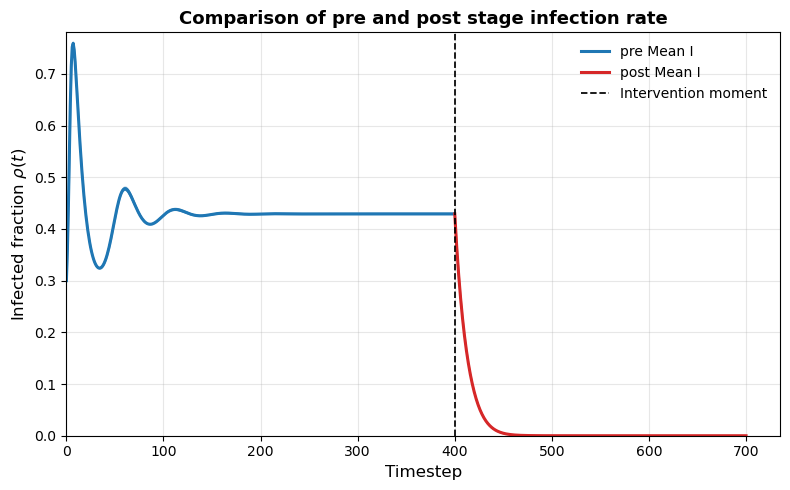

------ 干预阶段统计 ------
实验次数 (使用对齐列数) R = 20
干预前稳态平均感染率 (mean over runs) : 0.4292
干预后末态平均感染率 (mean over runs) : 0.0000
平均重连/删除超边数: 2400.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# === user config ===
out_dir = "./stage_intervention_runs_fixed"   # <- 改为你的输出目录
plot_individual_runs = True   # 若 True 绘制每次实验的单条轨迹（浅线）
save_png = True               # 若 True 保存 png 到 out_dir
png_name = "compare_pre_post_rho.png"
# ====================

pre_file = os.path.join(out_dir, "pre_rho_all.csv")
post_file = os.path.join(out_dir, "post_rho_all.csv")
summary_file = os.path.join(out_dir, "summary_stage_intervention.csv")

# 检查文件
for fn in (pre_file, post_file, summary_file):
    if not os.path.exists(fn):
        print(f"[ERROR] 找不到文件: {fn}", file=sys.stderr)
        raise FileNotFoundError(fn)

# 读取数据
pre_rho_all = pd.read_csv(pre_file, header=None).to_numpy()   # shape: (T_pre, R)
post_rho_all = pd.read_csv(post_file, header=None).to_numpy() # shape: (T_post, R)
df_summary = pd.read_csv(summary_file)

# dims
T_pre, R_pre = pre_rho_all.shape
T_post, R_post = post_rho_all.shape
if R_pre != R_post:
    print(f"[WARNING] pre 有 {R_pre} 列, post 有 {R_post} 列（列数应等于重复实验次数 R）。将分别处理。")

R = min(R_pre, R_post)   # 用最小的列数来对齐展示（若不对齐）
print(f"读取到: pre.shape={pre_rho_all.shape}, post.shape={post_rho_all.shape}, summary rows={len(df_summary)}")

# 截取对齐列（如果存在多余列）
if R_pre != R_post:
    pre_rho_all = pre_rho_all[:, :R]
    post_rho_all = post_rho_all[:, :R]

# 统计量
mean_pre = pre_rho_all.mean(axis=1)
std_pre  = pre_rho_all.std(axis=1)
mean_post = post_rho_all.mean(axis=1)
std_post  = post_rho_all.std(axis=1)

# 时间轴（注意 pre 包含初始 t=0 所以长度为 T_pre）
t_pre = np.arange(T_pre)               # 0,1,...,T_pre-1
t_post = np.arange(T_post) + T_pre    # post 起始于 T_pre

# 绘图
plt.figure(figsize=(8,5))

# individual runs (optional)
if plot_individual_runs:
    alpha_line = 0.25
    for col in range(R):
        plt.plot(t_pre, pre_rho_all[:, col], color='#1f77b4', alpha=alpha_line, linewidth=0.9)
        plt.plot(t_post, post_rho_all[:, col], color='#d62728', alpha=alpha_line, linewidth=0.9)

# mean + std bands
plt.plot(t_pre, mean_pre, color='#1f77b4', lw=2.2, label='pre Mean I')
plt.fill_between(t_pre, mean_pre - std_pre, mean_pre + std_pre, color='#1f77b4', alpha=0.25)

plt.plot(t_post, mean_post, color='#d62728', lw=2.2, label='post Mean I')
plt.fill_between(t_post, mean_post - std_post, mean_post + std_post, color='#d62728', alpha=0.25)

# intervention vertical line at the junction
intervention_t = T_pre   # intervention happens after pre segment
plt.axvline(intervention_t, color='k', linestyle='--', lw=1.25, label='Intervention moment')

# aesthetics
plt.xlabel("Timestep", fontsize=12)
plt.ylabel(r"Infected fraction $\rho(t)$", fontsize=12)
plt.title("Comparison of pre and post stage infection rate", fontsize=13, fontweight='bold')
plt.xlim(left=0)
# set reasonable ylim (0..1)
ymin = min(np.min(mean_pre - std_pre), np.min(mean_post - std_post))
ymax = max(np.max(mean_pre + std_pre), np.max(mean_post + std_post))
ymin = max(0.0, ymin - 0.02)
ymax = min(1.0, ymax + 0.02)
plt.ylim(ymin, ymax)

plt.grid(alpha=0.3)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()

# save & show
if save_png:
    out_png = os.path.join(out_dir, png_name)
    plt.savefig(out_png, dpi=300)
    print(f"Saved figure to {out_png}")

plt.show()

# 统计打印
print("------ 干预阶段统计 ------")
print(f"实验次数 (使用对齐列数) R = {R}")
if 'pre_ss_rho_mean' in df_summary.columns:
    print(f"干预前稳态平均感染率 (mean over runs) : {df_summary['pre_ss_rho_mean'].mean():.4f}")
if 'post_end_rho_mean' in df_summary.columns:
    print(f"干预后末态平均感染率 (mean over runs) : {df_summary['post_end_rho_mean'].mean():.4f}")
if 'num_rewired' in df_summary.columns:
    print(f"平均重连/删除超边数: {df_summary['num_rewired'].mean():.1f}")
